# <font color=#F90499>**Modelo Hackathonnn**</font>
***

## <font color=#05C0F3>**Introduccion al problema**</font>

### **Sector del negocio**

Atención al cliente / Marketing / Operaciones — empresas que recopilan opiniones de clientes (reseñas, comentarios en redes sociales, encuestas de satisfacción) y quieren entender rápidamente si el sentimiento es positivo, neutro o negativo.
***

### **Descripción del proyecto**

Crear una API simple que recibe textos (comentarios, reseñas o tweets), aplica un modelo de Data Science para clasificar el sentimiento (Atrasado / Puntual → en este caso: Positivo / Neutro / Negativo o binario Positivo / Negativo) y devuelve el resultado en formato JSON, permitiendo que las aplicaciones consuman esta predicción automáticamente.
***

### **Necesidad del cliente (explicación no técnica)**

Un cliente (empresa) recibe muchos comentarios y no puede leerlos todos manualmente. Quiere:

1. saber rápidamente si los clientes se están quejando o elogiando;

2. priorizar respuestas a comentarios negativos;

3. medir la satisfacción a lo largo del tiempo.

Este proyecto ofrece una solución automática para clasificar mensajes y generar información accionable.
***

### **Validación de mercado**

Analizar si el sentimiento es útil para:

- acelerar la atención al cliente (identificar urgencias);

- monitorear campañas de marketing;

- comparar la imagen de la marca a lo largo del tiempo.

Incluso una solución simple (modelo básico) tiene valor: las pequeñas y medianas empresas utilizan herramientas similares para entender los feedbacks sin un equipo dedicado.
***

### **Expectativa para este hackathon**

**Público:** estudiantes sin experiencia profesional en el área de tecnología, que estudiaron Back-end (Java, Spring, REST, persistencia) y Data Science (Python, Pandas, scikit-learn, notebooks).

**Objetivo:** entregar un MVP funcional que demuestre la integración entre DS y Back-end: un notebook con el modelo + una API que carga ese modelo y responde a las peticiones.

**Alcance recomendado:** clasificación binaria (Positivo / Negativo) o ternaria (Positivo / Neutro / Negativo) con un modelo simple — por ejemplo, usar TF-IDF (una técnica que transforma el texto en números, mostrando qué palabras son más importantes) junto con Regresión Logística (un modelo de aprendizaje automático que aprende a diferenciar sentimientos).
***

### **Entregables deseados**

Notebook (Jupyter/Colab) del equipo de Data Science que contenga:

1. Exploración y limpieza de los datos (EDA);

2. Transformación de los textos en números con TF-IDF;

3. Entrenamiento de modelo supervisado (ej.: Logistic Regression, Naive Bayes);

4. Métricas de desempeño (Accuracy, Precision, Recall, F1-score);

5. Serialización del modelo (joblib/pickle).
***

### **Documentación mínima (README):**

- Cómo ejecutar el modelo.

- Dependencias y versiones de las herramientas.

- Demonstración funcional (Presentación corta).

- Explicar cómo el modelo llega a la predicción.
***

### **Funcionalidades exigidas (MVP)**

1. El servicio debe exponer un endpoint que devuelve la clasificación del sentimiento y la probabilidad asociada a esa clasificación. Ejemplo: POST /sentiment — acepta JSON con campo text y devuelve: `{ "prevision": "Positivo", "probabilidad": 0.87 }`

2. Modelo entrenado y cargable: el back-end debe poder usar el modelo (cargando archivo) o hacer una petición a un microservicio DS que implemente la predicción.

3. Validación de input: verificar si text existe y tiene longitud mínima; devolver error amigable en caso contrario.

4. Respuesta clara: label (+ probabilidad en 0–1) y mensaje de error cuando sea aplicable.

5. Ejemplos de uso: Postman/cURL con 3 ejemplos reales (positivo, neutro, negativo).

6. README explicando cómo ejecutar (pasos simples) y cómo probar el endpoint.
***

### **Equipo de Data Science**

- Cada equipo debe elegir o armar su propio conjunto de datos de comentarios, reseñas o publicaciones que puedan utilizarse para el análisis de sentimientos (ej.: reviews públicos, tweets, evaluaciones de productos, etc.).

- usar Python, Pandas para leer/limpiar datos;

- crear un modelo simple (TF-IDF + LogisticRegression de scikit-learn);

- guardar el pipeline y el modelo con joblib.dump.

- Poner todo en un notebook bien comentado.
***

### **Contrato de integración (definido entre DS y BE)**


Recomendamos definir desde el principio el formato JSON de entrada y salida. Sigue un ejemplo:

{"text": "..."} →

{

"prevision":"Positivo",

"probabilidad":0.9

}
***

## <font color=#05C0F3>**Librerias**</font>

In [2]:
!pip install langdetect

In [3]:
import pandas as pd
# pd.set_option('display.max_colwidth', None)

import numpy as np

# Graficos
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_theme(style="whitegrid")

# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# Separador de datos de entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Modelo
from sklearn.linear_model import LogisticRegression

# Metricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluacion de metricas
from sklearn.metrics import classification_report

# Matriz de confusión
from sklearn.metrics import confusion_matrix

# Pipeline de prediccion
from sklearn.pipeline import Pipeline

# Serializacion
import joblib

#Detectar idiomas
from langdetect import detect

#Mezclar aleatoriamente
from sklearn.utils import shuffle

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Usuario\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
stops = set(stopwords.words('spanish'))
print(stops)

{'habrían', 'seríamos', 'tengo', 'estuvierais', 'hemos', 'hayan', 'tuvimos', 'cual', 'estuvieron', 'nada', 'estados', 'sintiendo', 'sin', 'seas', 'nuestra', 'sobre', 'era', 'hubieras', 'estaban', 'estés', 'tenga', 'tuvieron', 'fuimos', 'estuviera', 'habréis', 'tuyas', 'tuvo', 'nuestros', 'habríamos', 'estamos', 'hubieran', 'más', 'este', 'mía', 'habremos', 'tengan', 'tu', 'contra', 'tendría', 'somos', 'suyo', 'uno', 'las', 'en', 'tendremos', 'estuvieran', 'tenida', 'sus', 'al', 'hubiera', 'tenemos', 'sí', 'mío', 'tendrían', 'ha', 'vuestras', 'estas', 'tienes', 'fuisteis', 'tú', 'tuvieras', 'algunas', 'fuesen', 'mi', 'estaría', 'les', 'lo', 'habrás', 'fui', 'tuyo', 'estadas', 'yo', 'suyas', 'habrías', 'sea', 'ese', 'tenidas', 'y', 'poco', 'hasta', 'no', 'estuvieseis', 'del', 'estuvieras', 'seríais', 'estuvimos', 'tuvieseis', 'suyos', 'mucho', 'habidos', 'tuya', 'eran', 'hubimos', 'vuestro', 'estará', 'tened', 'hube', 'seremos', 'estás', 'tanto', 'estáis', 'tuve', 'sentida', 'mías', 'hab

***

## <font color=#05C0F3>**Datos de comentarios de peliculas en IMDB**</font>

In [5]:
url = "https://media.githubusercontent.com/media/JhonatanO24/sentiment-api-equipo39/refs/heads/data-science/data_science/datasets/IMDB%20Dataset%20SPANISH.csv"
datos = pd.read_csv(url)

In [6]:
datos = datos[['review_es', 'sentimiento']]

In [7]:
display(datos)

,review_es,sentimiento
0,Uno de los otros críticos ha mencionado que de...,positivo
1,Una pequeña pequeña producción.La técnica de f...,positivo
2,Pensé que esta era una manera maravillosa de p...,positivo
3,"Básicamente, hay una familia donde un niño peq...",negativo
4,"El ""amor en el tiempo"" de Petter Mattei es una...",positivo
...,...,...
49995,Pensé que esta película hizo un buen trabajo a...,positivo
49996,"Mala parcela, mal diálogo, mala actuación, dir...",negativo
49997,Soy católica enseñada en escuelas primarias pa...,negativo
49998,Voy a tener que estar en desacuerdo con el com...,negativo


***

## <font color=#05C0F3>**Analisis exploratorio de datos**</font>
***

### **Muestreo Aleatorio**

In [8]:
datos.head(10)

,review_es,sentimiento
0,Uno de los otros críticos ha mencionado que de...,positivo
1,Una pequeña pequeña producción.La técnica de f...,positivo
2,Pensé que esta era una manera maravillosa de p...,positivo
3,"Básicamente, hay una familia donde un niño peq...",negativo
4,"El ""amor en el tiempo"" de Petter Mattei es una...",positivo
5,Probablemente mi película favorita de todos lo...,positivo
6,Seguro que me gustaría ver una resurrección de...,positivo
7,"Este espectáculo fue una idea increíble, fresc...",negativo
8,Alentados por los comentarios positivos sobre ...,negativo
9,"Si te gusta la risa original desgarradora, te ...",positivo


In [9]:
datos.tail(10)

,review_es,sentimiento
49990,"Cojo, cojo, cojo !!!Un festival de 90 minutos ...",negativo
49991,"Les Visiteurs, la primera película sobre los v...",negativo
49992,John Garfield interpreta a un marine que está ...,positivo
49993,Robert Colomb tiene dos trabajos a tiempo comp...,negativo
49994,Esta es tu comedia de chatarra típica. Casi no...,negativo
49995,Pensé que esta película hizo un buen trabajo a...,positivo
49996,"Mala parcela, mal diálogo, mala actuación, dir...",negativo
49997,Soy católica enseñada en escuelas primarias pa...,negativo
49998,Voy a tener que estar en desacuerdo con el com...,negativo
49999,Nadie espera que las películas de Star Trek se...,negativo


In [10]:
datos.sample(10)

,review_es,sentimiento
5799,"Aunque vi esta película hace años, su impacto ...",positivo
18575,El aeropuerto '77 comienza como un nuevo lujo ...,negativo
28268,(SPOILERS EN PRIMER PÁRRAFO) El sentimiento an...,positivo
47456,Mikhail Kalatozov Las grúas están volando son ...,positivo
33774,Aunque mi exposición a las culturas del mundo ...,negativo
7832,"Cuando vi la película al principio, pensé que ...",positivo
35067,Pensé que tal vez ... tal vez esto podría ser ...,negativo
43538,"Es realmente fácil de brindar, asado, Fley y, ...",negativo
43729,"Bellamente filmado, la mente expandiendo la ex...",positivo
10067,Nunca he conocido una película para despertar ...,positivo


### **Verificación de Dimensiones y Tipos**

In [11]:
print(f'Los datos tienen {datos.shape[0]} filas y {datos.shape[1]} columnas.')

Los datos tienen 50000 filas y 2 columnas.


In [12]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_es    50000 non-null  object
 1   sentimiento  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


### **Eliminando duplicados**

In [13]:
datos.shape

(50000, 2)

In [14]:
datos = datos.drop_duplicates()

In [15]:
datos.shape

(49599, 2)

Se eliminan 401 duplicados

### **Longitud de los textos**

In [16]:
datos.describe()

,review_es,sentimiento
count,49599,49599
unique,49599,2
top,Uno de los otros críticos ha mencionado que de...,positivo
freq,1,24886


In [17]:
datos['review_es'].describe()

count                                                 49599
unique                                                49599
top       Uno de los otros críticos ha mencionado que de...
freq                                                      1
Name: review_es, dtype: object

In [18]:
datos['n_palabras'] = datos['review_es'].str.split().str.len() # Separa todas las palabras del comentario y las cuenta
datos['n_palabras']

0        345
1        161
2        173
3        137
4        237
        ... 
49995    170
49996    105
49997    246
49998    232
49999    122
Name: n_palabras, Length: 49599, dtype: int64

In [19]:
datos['n_palabras'].describe()

count    49599.000000
mean       237.436884
std        179.696966
min          6.000000
25%        124.000000
50%        173.000000
75%        293.000000
max       2450.000000
Name: n_palabras, dtype: float64

#### Longitud extrema: análisis más profundo de outliers

In [20]:
datos['n_palabras'].quantile([0.90, 0.95, 0.99])

0.90    474.0
0.95    623.0
0.99    913.0
Name: n_palabras, dtype: float64

In [21]:
pd.set_option('display.max_colwidth', None)

In [22]:
datos.loc[datos['n_palabras'] > 1000, 'review_es'].sample(1)

5708    **Attention Spoilers**First of all, let me say that Rob Roy is one of the best films of the 90's It was an amazing achievement for all those involved, especially the acting of Liam Neeson, Jessica Lange, John Hurt, Brian Cox, and Tim Roth Michael Canton Jones painted a wonderful portrait of the honor and dishonor that men can represent in themselves But alasit constantly, and unfairly gets compared to "Braveheart" These are two entirely different films, probably only similar in the fact that they are both about Scots in historical Scotland Yet, this comparison frequently bothers me because it seems to be almost assumed that "Braveheart" is a better film than "Rob Roy" I like "Braveheart" a lot, but the idea of comparing it to "Rob Roy" is a little insulting to me To put quite simply, I love "Braveheart", but it is a pale shadow to how much I love "Rob Roy" Here are my particular reasons-"Rob Roy" is about real peopleLet's face it, the William Wallace in "Braveheart" is not a re

In [23]:
datos[['review_es', 'n_palabras']].query('n_palabras > 500').sample(10)

review_es  \
37184                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  Spoilers en esta revisión! A pesar de algunas escenas altamente improbables, incluidos los niños en PE, midiendo sus penes en un concurso y los pocos viñetas obligatorias, captura la esencia dolorosa de la escuela secundaria de manera que las pocas películas de adolescentes hayan hecho. Logra esto al no solo mostrando el trío de amigos, Gary, Dave, Rick, como fumar, beber, nunca en los adolescentes de merodeos, sino que también habita en la naturaleza de la amistad, ya que estos tres amigos tienen sus lealtades probadas. Esta película es una instantánea de la hora en que termina la infancia. Para el tímido romántico Gary, cuando ve a los encantadores Karen por primera vez, se enamora al instante. La emoción del despertar en Gary es muy grande en la pantalla, y él demuestra su amor por ella llevándola cuando está jiltada por su amante. Este amor por Karen señala el final de la inocencia de Gary, ya que los bonos con sus dos mejores amigos serán probados, y se romperán, a lo largo de la historia. El hombre confiado, Rick, es la persona en la escuela secundaria, todos deseamos en secreto que éramos: guapo, fresco, y siempre tiene las niñas increíblemente hermosas en un desmayo. Rick resulta ser un CAD, pero tienes que tener en cuenta que su personaje tiene solo 17 años. Él pánico y toma una mala decisión. Desde la perspectiva de Rick, la historia también se trata de encontrar a la única chica de sus sueños, una mala ruptura, y luego, al final, conciliando. La mirada en la cara de Rick mientras Gary entra y ve a Karen besando a Rick, muestra que, por fin, entiende que su mejor amigo y él ama a la misma mujer. Como en la vida real, no se inclinas porque tu amigo tiene un amor no correspondido. Esta es la tragedia de la película. Rick no es un villano, y constantemente a través de la película, le recuerda a Gary y Dave que son sus mejores amigos. La calidad conmovedora del desempeño de Gary, sin embargo, es el corazón de la historia. Lawrence Monoson es un hermoso perdedor. Él hace todo bien, su corazón está en el lugar correcto, y él ha consumido por el amor por Karen. Sin embargo, Karen, al final, no es movido por la devoción y la amabilidad de Gary. Karen representa a todas las personas en el mundo que disfrutan sin

In [24]:
pd.set_option('display.max_colwidth', 50)

### **Verificar la distribución de la columna objetivo (Sentimiento)**

In [25]:
datos['sentimiento'].value_counts()

sentimiento
positivo    24886
negativo    24713
Name: count, dtype: int64

In [26]:
datos['sentimiento'].value_counts(normalize=True)

sentimiento
positivo    0.501744
negativo    0.498256
Name: proportion, dtype: float64

In [27]:
datos.sample(10)

,review_es,sentimiento,n_palabras
30492,¿Quieres una película que te llevará lugares?B...,positivo,154
9792,"No tengo nada que comentar en esta película, e...",negativo,124
12506,Cuatro o cinco episodios de Johnnie Socko y su...,positivo,138
43153,Mary Tyler Moore y Valerie Harper aún pueden c...,positivo,80
42006,Tomó un muy buen libro y completamente lo mató...,negativo,47
42509,"Este fue un excelente episodio, uno de los mej...",positivo,184
39111,Gracias por hacer un escape tan maravilloso.Es...,positivo,125
306,Me considero un poco de un conocedor de pelícu...,positivo,302
19849,"Imagina la difícil situación de Richard, un pi...",positivo,496
31796,Oh mi.Decidí salir a los cines con algunos ami...,negativo,120


### **Graficos**

In [28]:
sns.axes_style()

{'axes.facecolor': 'white',
 'axes.edgecolor': '.8',
 'axes.grid': True,
 'axes.axisbelow': True,
 'axes.labelcolor': '.15',
 'figure.facecolor': 'white',
 'grid.color': '.8',
 'grid.linestyle': '-',
 'text.color': '.15',
 'xtick.color': '.15',
 'ytick.color': '.15',
 'xtick.direction': 'out',
 'ytick.direction': 'out',
 'lines.solid_capstyle': <CapStyle.round: 'round'>,
 'patch.edgecolor': 'w',
 'patch.force_edgecolor': True,
 'image.cmap': 'rocket',
 'font.family': ['sans-serif'],
 'font.sans-serif': ['Arial',
  'DejaVu Sans',
  'Liberation Sans',
  'Bitstream Vera Sans',
  'sans-serif'],
 'xtick.bottom': False,
 'xtick.top': False,
 'ytick.left': False,
 'ytick.right': False,
 'axes.spines.left': True,
 'axes.spines.bottom': True,
 'axes.spines.right': True,
 'axes.spines.top': True}

In [29]:
sns.set_theme(
    style="darkgrid",
    font_scale=1.1
)

### Colores

In [30]:
color_primario = "#05C0F3"
color_secundario = "#F90499"

#### Histograma

¿Cómo es la distribución del tamaño de los textos (reviews) que usaremos para entrenar el modelo de sentimiento?

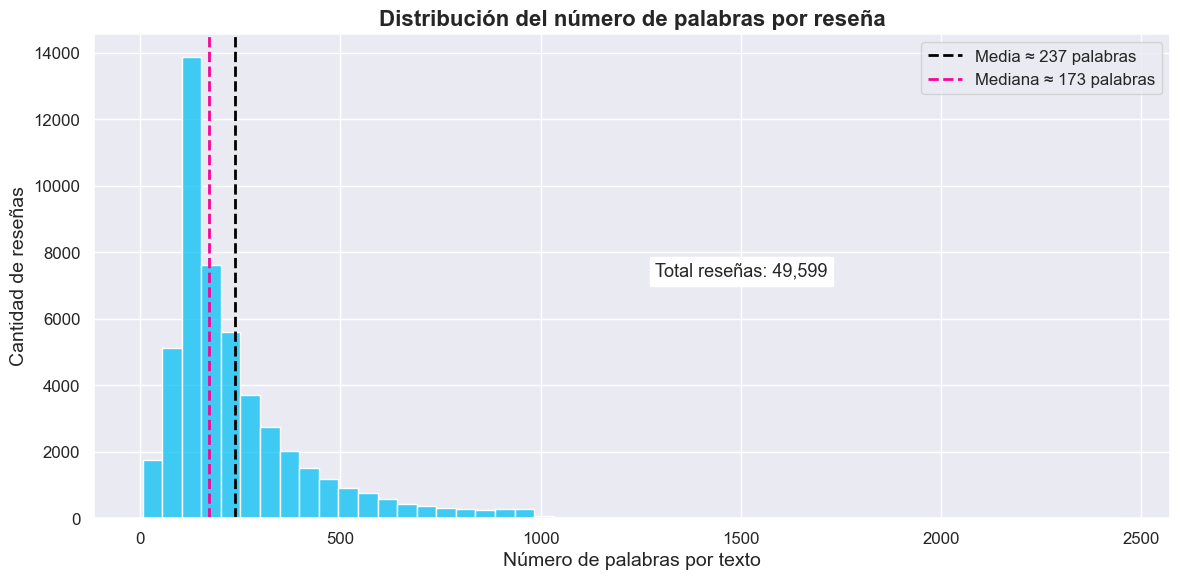

In [31]:
def distribucion_numero_palabras_por_reseña():
  plt.figure(figsize=(12, 6))

  sns.histplot(
      datos['n_palabras'],
      bins = 50,
      color = color_primario
      )

  plt.title(
      "Distribución del número de palabras por reseña",
      fontsize = 16,
      fontweight = "bold"
  )

  plt.xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  plt.ylabel(
      "Cantidad de reseñas",
      fontsize = 14
  )

  media = datos['n_palabras'].mean()
  plt.axvline( # muestra la linea punteada que señala el promedio
      media,
      color = 'black',
      linestyle = "--",
      linewidth = 2,
      label = f"Media ≈ {media:.0f} palabras"
  )
  # Línea de referencia: mediana
  mediana = datos['n_palabras'].median()
  plt.axvline(
      mediana,
      color=color_secundario,
      linestyle="--",
      linewidth=2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )

  plt.text(
      0.50 * plt.xlim()[1],
      0.50 * plt.ylim()[1],
      f"Total reseñas: {len(datos):,}",
      fontsize=13,
      bbox=dict(facecolor="white")
  )

  plt.legend() # Muestra la leyenda
  plt.tight_layout()
  plt.show()

distribucion_numero_palabras_por_reseña()

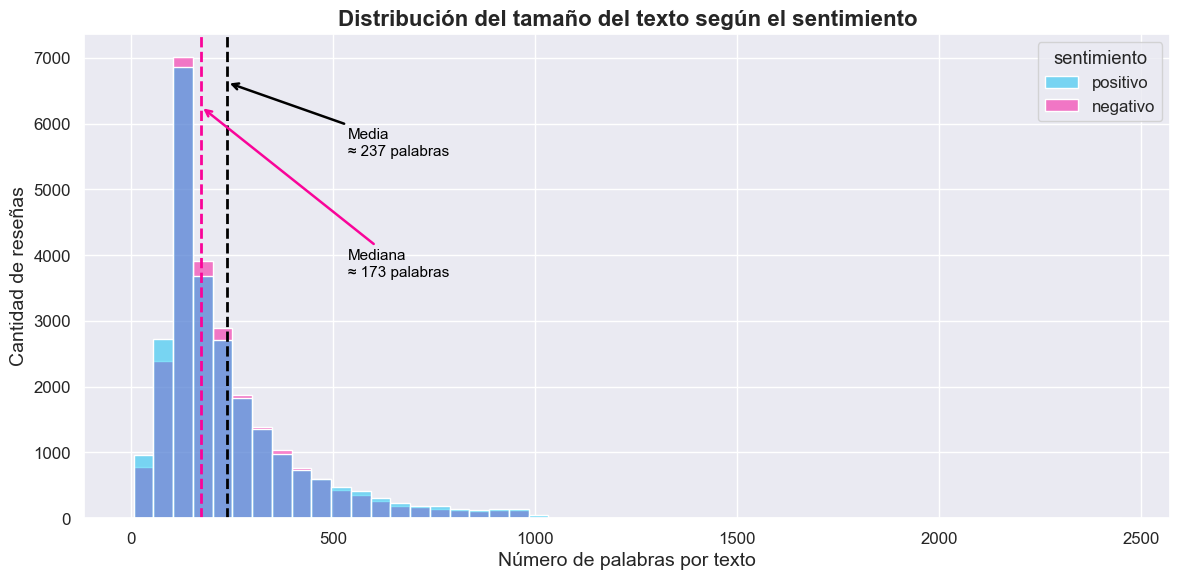

In [32]:
def distribucion_numero_palabras_por_reseña_por_sentimiento():
  fig, ax = plt.subplots(figsize=(12,6))

  sns.histplot(
      data = datos,
      x = 'n_palabras',
      hue = 'sentimiento',
      palette = [color_primario, color_secundario],
      bins=50
  )

  ax.set_title(
      "Distribución del tamaño del texto según el sentimiento",
      fontsize = 16,
      fontweight = "bold"
  )

  ax.set_xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  ax.set_ylabel(
      "Cantidad de reseñas",
      fontsize = 14
  )

  media = datos['n_palabras'].mean()
  ax.axvline( # muestra la linea punteada que señala el promedio
      media,
      color = 'black',
      linestyle = "--",
      linewidth = 2,
      label = f"Media ≈ {media:.0f} palabras"
  )
  # Línea de referencia: mediana
  mediana = datos['n_palabras'].median()
  ax.axvline(
      mediana,
      color = color_secundario,
      linestyle = "--",
      linewidth = 2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )

  ax.annotate(
      f"Media\n≈ {media:.0f} palabras",
      xy = (media, ax.get_ylim()[1] * 0.9),      # apunta a la línea
      xytext = (media + 300, ax.get_ylim()[1] * 0.75),
      arrowprops = dict(
            arrowstyle = "->",
            color = 'black',
            linewidth = 1.8
            ),
      fontsize = 11,
      color = 'black'
      )

  texto_moda = ('Mediana')
  ax.annotate(
      f"Mediana\n≈ {mediana:.0f} palabras",
        xy = (mediana, ax.get_ylim()[1] * 0.85),      # apunta a la línea
      xytext = (media + 300, ax.get_ylim()[1] * 0.50),
      arrowprops = dict(
            arrowstyle = "->",
            color = color_secundario,
            linewidth = 1.8
            ),
      fontsize = 11,
      color = 'black'
      )

  plt.tight_layout()
  plt.show()

distribucion_numero_palabras_por_reseña_por_sentimiento()

#### Boxplot

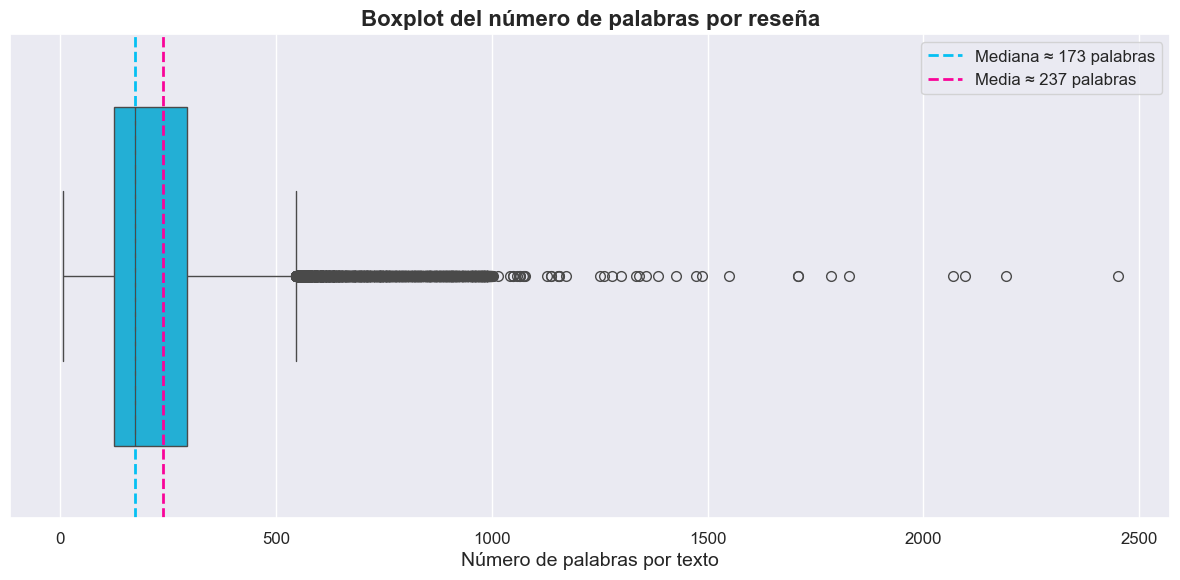

In [33]:
def boxplot_numero_palabras_por_reseña():
  plt.figure(figsize=(12, 6))

  sns.boxplot(
      x = datos['n_palabras'],
      color = color_primario,
      width = 0.7, # Tamaño del boxplot
      fliersize = 7, # Tamaño de los puntos atípicos
  )

  plt.title(
      "Boxplot del número de palabras por reseña",
      fontsize = 16,
      fontweight = "bold"
  )

  plt.xlabel(
      "Número de palabras por texto",
      fontsize = 14
  )

  # Línea de referencia: mediana
  mediana = datos['n_palabras'].median()
  plt.axvline(
      mediana,
      color=color_primario,
      linestyle="--",
      linewidth=2,
      label=f"Mediana ≈ {mediana:.0f} palabras"
  )
  # Línea de referencia: media
  media = datos['n_palabras'].mean()
  plt.axvline(
      media,
      color=color_secundario,
      linestyle="--",
      linewidth=2,
      label=f"Media ≈ {media:.0f} palabras"
  )


  plt.legend()
  plt.tight_layout()
  plt.show()

boxplot_numero_palabras_por_reseña()

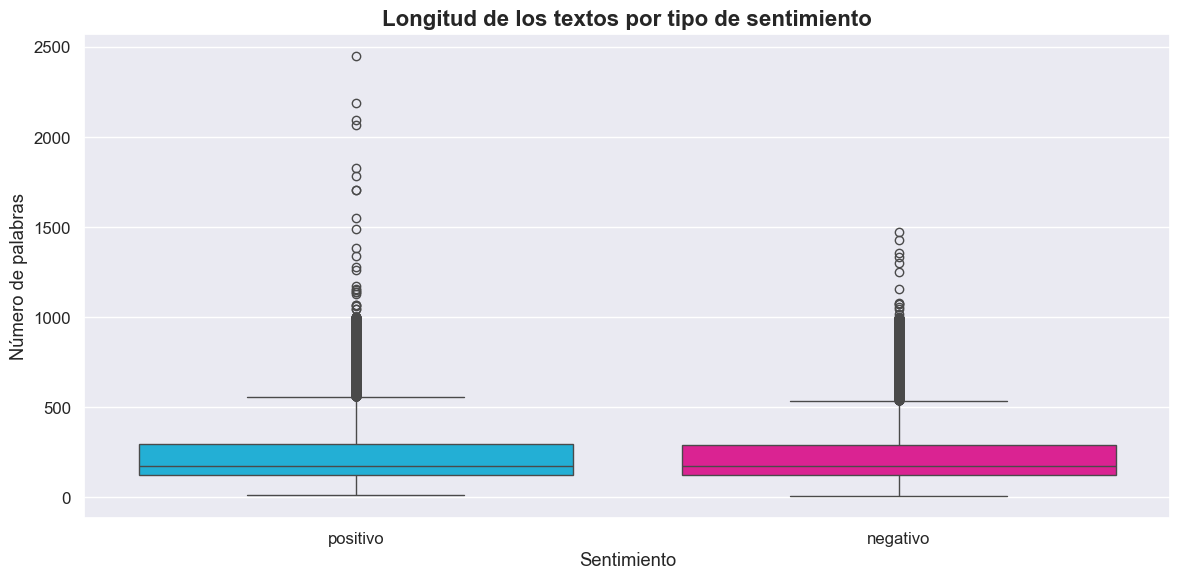

In [34]:
def boxplot_numero_palabras_por_reseña_por_sentimiento():
  plt.figure(figsize=(12,6))

  sns.boxplot(
      data = datos,
      x='sentimiento',
      y = 'n_palabras',
      hue = 'sentimiento',
      palette = [color_primario, color_secundario]
  )

  plt.title(
      "Longitud de los textos por tipo de sentimiento",
      fontsize=16,
      fontweight="bold"
      )

  plt.xlabel("Sentimiento")

  plt.ylabel("Número de palabras")

  plt.tight_layout()
  plt.show()

boxplot_numero_palabras_por_reseña_por_sentimiento()

### **Conclusion**

#### **Conclusiones sobre la calidad de los datos**

* El conjunto de datos presenta algunos registros duplicados pero pocos comparados a la cantidad de datos, lo que indica una buena calidad inicial, además de que con la limpieza se eliminan para evitar sesgos por repetición de observaciones durante el entrenamiento del modelo.

* Las columnas cuentan con tipos de datos adecuados para el análisis, permitiendo trabajar correctamente con texto y variables categóricas.

#### **Conclusiones sobre la longitud de los textos**

- La longitud de las reseñas presenta alta variabilidad, con una media aproximada de 237 palabras y valores extremos que alcanzan más de 2400 palabras.

- La diferencia entre media y mediana indica una distribución sesgada a la derecha, confirmada por la presencia de múltiples outliers visibles en el boxplot.

- La mayoría de los textos se concentra en rangos bajos y medios de longitud, mientras que un pequeño porcentaje de reseñas muy extensas genera una cola larga en la distribución.

#### **Conclusiones sobre el idioma de los datos**

- Se detectó la presencia de reseñas en más de un idioma (español e inglés) dentro de la columna utilizada para el entrenamiento.

- Esto introduce un posible ruido lingüístico, ya que TF-IDF tratará palabras de ambos idiomas como parte del mismo vocabulario.

#### **Conclusión general del EDA**

El análisis exploratorio confirma que el conjunto de datos es apto para entrenar un modelo de análisis de sentimiento, cumpliendo con los requisitos del MVP propuesto.

Si bien existen desafíos como la alta variabilidad en la longitud de los textos y la presencia de múltiples idiomas, estos no impiden la construcción de un modelo inicial basado en TF-IDF y regresión logística.

El EDA permite identificar claramente oportunidades de mejora que pueden abordarse en iteraciones futuras, alineándose con el enfoque incremental esperado.

## <font color=#05C0F3>**Limpieza de datos**</font>

### **Tratamiento de Valores Nulos e Inconsistencias**

#### Conteo de valores nulos

In [35]:
datos.isnull().sum()

review_es      0
sentimiento    0
n_palabras     0
dtype: int64

No hay valores nulos en ninguna columna

### **Limpieza y Normalización del Texto**

#### Eliminar reseñas en inglés

In [36]:
def detectar_idioma(texto):
    try:
        return detect(texto) #Se usa la biblioteca langdetect
    except:
        return "desconocido"

In [37]:
datos.shape

(49599, 3)

In [38]:
#Columna con el idioma de la reseña (El procesamiento tardará)
datos['idioma_detectado'] = datos['review_es'].apply(detectar_idioma)

In [39]:
datos_limpios = datos[datos['idioma_detectado'] == 'es'].copy() #Solo guarda los datos en español

In [40]:
filas_originales = len(datos)
filas_limpias = len(datos_limpios)
print(f"Se eliminaron {filas_originales - filas_limpias} filas que no estaban en español")

Se eliminaron 1815 filas que no estaban en español


In [41]:
datos = datos_limpios

In [42]:
datos.shape

(47784, 4)

#### Verificar la distribución de la columna objetivo (Sentimiento)

In [43]:
datos['sentimiento'].value_counts()

sentimiento
positivo    23935
negativo    23849
Name: count, dtype: int64

In [44]:
print("\nEstadísticas de longitud antes del balanceo:")
print(datos.groupby('sentimiento')['n_palabras'].describe())


Estadísticas de longitud antes del balanceo:
               count        mean         std   min    25%    50%    75%    max
sentimiento                                                                   
negativo     23849.0  227.789090  157.364916   6.0  125.0  172.0  284.0  998.0
positivo     23935.0  230.686693  166.550784  10.0  122.0  170.0  290.0  955.0


#### Eliminar las reseñas más grandes (partes del sesgo) para mantener el equilibrio en el número de reseñas de ambos sentimientos

In [45]:
datos_pos = datos[datos['sentimiento'] == 'positivo'].copy()
datos_neg = datos[datos['sentimiento'] == 'negativo'].copy()

In [46]:
diferencia = len(datos_pos) - len(datos_neg)
print(f"Hay {diferencia} reseñas positivas extras")

Hay 86 reseñas positivas extras


In [47]:
datos_pos_balanceado = datos_pos.sort_values(by='n_palabras', ascending=False).iloc[diferencia:]
len(datos_pos_balanceado)

23849

In [48]:
datos_equilibrados = pd.concat([datos_pos_balanceado, datos_neg])

In [49]:
datos = shuffle(datos_equilibrados, random_state=42).reset_index(drop=True)

In [50]:
datos['sentimiento'].value_counts()

sentimiento
negativo    23849
positivo    23849
Name: count, dtype: int64

In [51]:
print("\nEstadísticas de longitud tras el balanceo:")
print(datos.groupby('sentimiento')['n_palabras'].describe())


Estadísticas de longitud tras el balanceo:
               count        mean         std   min    25%    50%    75%    max
sentimiento                                                                   
negativo     23849.0  227.789090  157.364916   6.0  125.0  172.0  284.0  998.0
positivo     23849.0  228.243406  161.791663  10.0  121.0  169.0  289.0  883.0


#### Estandarización a minúsculas

In [52]:
display(datos)

,review_es,sentimiento,n_palabras,idioma_detectado
0,Me derrota absolutamente por qué Godard se tom...,negativo,328,es
1,"¿Nunca debo ir a este hospital [o hospicio, si...",positivo,127,es
2,"Alan Rudolph es un director tan así, sin ese t...",negativo,233,es
3,Alquilé esto pensando que sería bastante bueno...,negativo,105,es
4,"La serie Azul Planet es, sin lugar a dudas, un...",positivo,209,es
...,...,...,...,...
47693,Crecí en la ciudad de Nueva York y todas las t...,positivo,179,es
47694,96 minutos de esto es cruel ... y amo a los an...,negativo,407,es
47695,"Oh hombre, ¿esta película alguna vez muerde!Si...",negativo,72,es
47696,"Sin duda, una de las grandes obras maestras de...",positivo,636,es


In [53]:
datos['review_es_limpio'] = datos['review_es'].str.lower()

In [54]:
datos['review_es_limpio']

0        me derrota absolutamente por qué godard se tom...
1        ¿nunca debo ir a este hospital [o hospicio, si...
2        alan rudolph es un director tan así, sin ese t...
3        alquilé esto pensando que sería bastante bueno...
4        la serie azul planet es, sin lugar a dudas, un...
                               ...                        
47693    crecí en la ciudad de nueva york y todas las t...
47694    96 minutos de esto es cruel ... y amo a los an...
47695    oh hombre, ¿esta película alguna vez muerde!si...
47696    sin duda, una de las grandes obras maestras de...
47697    pensé que esta película estaba muy bien hecha....
Name: review_es_limpio, Length: 47698, dtype: object

#### Eliminación de caracteres especiales y números

Se usa regex (expresiones regulares) para remover símbolos, números o puntuación, lo cual es esencial para el procesamiento de texto

In [55]:
datos['review_es_limpio'] = datos['review_es_limpio'].str.replace(r'[^a-záéíóúñü\s]', '', regex=True)


In [56]:
display(datos['review_es_limpio'])

0        me derrota absolutamente por qué godard se tom...
1        nunca debo ir a este hospital o hospicio si qu...
2        alan rudolph es un director tan así sin ese to...
3        alquilé esto pensando que sería bastante bueno...
4        la serie azul planet es sin lugar a dudas uno ...
                               ...                        
47693    crecí en la ciudad de nueva york y todas las t...
47694     minutos de esto es cruel  y amo a los antiguo...
47695    oh hombre esta película alguna vez muerdesi al...
47696    sin duda una de las grandes obras maestras de ...
47697    pensé que esta película estaba muy bien hechat...
Name: review_es_limpio, Length: 47698, dtype: object

`[^a-záéíóúñü\s]`

Significa:
  Cualquier carácter que NO sea:
  - letras minúsculas
  - letras con tilde
  - ñ, ü
  - espacios

In [57]:
# Reduce repeticiones excesivas de caracteres:
# Ej: "bueeeno" → "bueeno", "holaaaa" → "holaa"
datos['review_es_limpio'] = datos['review_es_limpio'].str.replace(
    r'(.)\1{2,}', r'\1\1', regex=True
)

Se decidió normalizar las secuencias de un mismo carácter repetido
3 o más veces, reduciéndolas a un máximo de 2 repeticiones.

Esta decisión permite:
- Reducir la variabilidad innecesaria del vocabulario
- Conservar parte de la intención emocional del texto
- Mejorar la calidad del texto para tareas de NLP como análisis de sentimiento

La normalización de caracteres repetidos se aplica para evitar que variaciones
ortográficas no semánticas afecten la tokenización y el desempeño del modelo.
Se conserva un máximo de dos repeticiones para no eliminar completamente
el énfasis expresivo del lenguaje informal.

#### Eliminar espacios múltiples

In [58]:
datos['review_es_limpio'] = datos['review_es_limpio'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [59]:
display(datos['review_es_limpio'])

0        me derrota absolutamente por qué godard se tom...
1        nunca debo ir a este hospital o hospicio si qu...
2        alan rudolph es un director tan así sin ese to...
3        alquilé esto pensando que sería bastante bueno...
4        la serie azul planet es sin lugar a dudas uno ...
                               ...                        
47693    crecí en la ciudad de nueva york y todas las t...
47694    minutos de esto es cruel y amo a los antiguos ...
47695    oh hombre esta película alguna vez muerdesi al...
47696    sin duda una de las grandes obras maestras de ...
47697    pensé que esta película estaba muy bien hechat...
Name: review_es_limpio, Length: 47698, dtype: object

## <font color=#05C0F3>**Transformación de Características (Feature Engineering)**</font>

In [60]:
display(datos)

,review_es,sentimiento,n_palabras,idioma_detectado,review_es_limpio
0,Me derrota absolutamente por qué Godard se tom...,negativo,328,es,me derrota absolutamente por qué godard se tom...
1,"¿Nunca debo ir a este hospital [o hospicio, si...",positivo,127,es,nunca debo ir a este hospital o hospicio si qu...
2,"Alan Rudolph es un director tan así, sin ese t...",negativo,233,es,alan rudolph es un director tan así sin ese to...
3,Alquilé esto pensando que sería bastante bueno...,negativo,105,es,alquilé esto pensando que sería bastante bueno...
4,"La serie Azul Planet es, sin lugar a dudas, un...",positivo,209,es,la serie azul planet es sin lugar a dudas uno ...
...,...,...,...,...,...
47693,Crecí en la ciudad de Nueva York y todas las t...,positivo,179,es,crecí en la ciudad de nueva york y todas las t...
47694,96 minutos de esto es cruel ... y amo a los an...,negativo,407,es,minutos de esto es cruel y amo a los antiguos ...
47695,"Oh hombre, ¿esta película alguna vez muerde!Si...",negativo,72,es,oh hombre esta película alguna vez muerdesi al...
47696,"Sin duda, una de las grandes obras maestras de...",positivo,636,es,sin duda una de las grandes obras maestras de ...


### **Definición de variables de entrada (X) y salida (y)**

In [61]:
X = datos['review_es_limpio']

In [62]:
display(X)

0        me derrota absolutamente por qué godard se tom...
1        nunca debo ir a este hospital o hospicio si qu...
2        alan rudolph es un director tan así sin ese to...
3        alquilé esto pensando que sería bastante bueno...
4        la serie azul planet es sin lugar a dudas uno ...
                               ...                        
47693    crecí en la ciudad de nueva york y todas las t...
47694    minutos de esto es cruel y amo a los antiguos ...
47695    oh hombre esta película alguna vez muerdesi al...
47696    sin duda una de las grandes obras maestras de ...
47697    pensé que esta película estaba muy bien hechat...
Name: review_es_limpio, Length: 47698, dtype: object

In [63]:
y = datos['sentimiento'].map({
    'negativo': 0,
    'positivo': 1
})

Se transforman los datos de la variable `y` ya que Logistic Regression no permite trabajar con datos tipo string

In [64]:
display(y)

0        0
1        1
2        0
3        0
4        1
        ..
47693    1
47694    0
47695    0
47696    1
47697    1
Name: sentimiento, Length: 47698, dtype: int64

### **División de datos en conjuntos de entrenamiento y prueba**

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.3,
    random_state = 42,
    stratify = y
)

### **Inicialización del Vectorizador TF-IDF**

El TF-IDF (Term Frequency-Inverse Document Frequency) es la técnica clave que transforma el texto en números, mostrando qué palabras son más importantes para cada documento/reseña.

In [66]:
stopwords_es = set(stopwords.words('spanish'))

In [67]:
palabras_vitales = {'no', 'ni', 'sin', 'pero', 'nunca', 'jamás', 'tampoco', 'es', 'esta', 'está', 'fue', 'era', 'son', 'ser'}

In [68]:
stopwords_final = [w for w in stopwords_es if w not in palabras_vitales]

In [69]:
vectorizador = TfidfVectorizer(
    stop_words = stopwords_final,
    ngram_range = (1, 3),
    max_features = 25_000,
    strip_accents='unicode',
    min_df = 5,
    max_df = 0.9,
    sublinear_tf = True
)

In [70]:
print(f"¿'no' es stopword?: {'no' in stopwords_final}") # Debe ser False
print(f"¿'la' es stopword?: {'la' in stopwords_final}") # Debe ser True

¿'no' es stopword?: False
¿'la' es stopword?: True


stop_words=stopwords_personalizadas
Se usan stopwords en español, pero se conservan negaciones como “no”, “pero”, “sin” para no perder información semántica clave en el sentimiento.

- `ngram_range=(1, 3)`
Incluye unigramas, bigramas y trigramas para capturar tanto palabras individuales como expresiones con contexto y negación (“no me gusta”, “no es nada bueno”), mejorando la comprensión del significado del texto.

- `max_features=25_000`
Limita el vocabulario a los términos más informativos, manteniendo un equilibrio entre capacidad expresiva del modelo, rendimiento y costo computacional.

- `strip_accents='unicode'`
Normaliza los caracteres eliminando acentos, evitando duplicidades de términos y mejorando la consistencia del vocabulario, especialmente en textos en español.

- `min_df=5`
Elimina términos muy poco frecuentes, reduciendo ruido y aumentando la estabilidad del modelo.

- `max_df=0.9`
Excluye palabras demasiado comunes que no ayudan a diferenciar el sentimiento.

- `sublinear_tf=True`
Reduce el impacto de repeticiones excesivas de una palabra, evitando que dominen la representación del texto.

### **Ajuste (fit) y Transformación (transform) del conjunto de entrenamiento**

In [71]:
X_train_tfidf  = vectorizador.fit_transform(X_train)

c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['eramos', 'estabamos', 'estais', 'estan', 'estara', 'estaran', 'estaras', 'estare', 'estareis', 'estaria', 'estariais', 'estariamos', 'estarian', 'estarias', 'esteis', 'esten', 'estes', 'estuvieramos', 'estuviesemos', 'fueramos', 'fuesemos', 'habeis', 'habia', 'habiais', 'habiamos', 'habian', 'habias', 'habra', 'habran', 'habras', 'habre', 'habreis', 'habria', 'habriais', 'habriamos', 'habrian', 'habrias', 'hayais', 'hubieramos', 'hubiesemos', 'mas', 'mia', 'mias', 'mio', 'mios', 'seais', 'sera', 'seran', 'seras', 'sere', 'sereis', 'seria', 'seriais', 'seriamos', 'serian', 'serias', 'si', 'tambien', 'tendra', 'tendran', 'tendras', 'tendre', 'tendreis', 'tendria', 'tendriais', 'tendriamos', 'tendrian', 'tendrias', 'teneis', 'tengais', 'tenia', 'teniais', 'te

In [72]:
display(X_train_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3983737 stored elements and shape (33388, 25000)>

### **Transformación del conjunto de prueba**

In [73]:
X_test_tfidf = vectorizador.transform(X_test)

In [74]:
display(X_test_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1678976 stored elements and shape (14310, 25000)>

#### Dimension

In [75]:
X_train_tfidf.shape

(33388, 25000)

In [76]:
X_test_tfidf.shape

(14310, 25000)

## <font color=#05C0F3>**Modelado y Evaluación**</font>

El modelo recomendado es la Regresión Logística, una técnica de clasificación supervisada simple y efectiva para este tipo de problemas.

### **Entrenamiento**

#### Inicialización del modelo de clasificación (Regresión Logística)

In [77]:
modelo = LogisticRegression(
    random_state = 42,
    max_iter = 1000,
    class_weight = 'balanced',
    solver = 'liblinear'
    )

Se utiliza Regresión Logística para la clasificación de sentimiento debido a su estabilidad, buen desempeño con texto vectorizado mediante TF-IDF y capacidad de devolver probabilidades, requisito clave para la API.


- `max_iter=1000`
Aumenta el número máximo de iteraciones para asegurar que el modelo tenga suficiente tiempo para converger correctamente, especialmente al trabajar con un gran número de características generadas por TF-IDF.

- `class_weight='balanced'`
Ajusta automáticamente el peso de cada clase, haciendo el modelo más robusto ante posibles desbalances y evitando sesgos en la predicción.

- `solver='liblinear'`
Selecciona un método de optimización estable y eficiente, especialmente adecuado para problemas de clasificación binaria con conjuntos de datos de tamaño medio y alta dimensionalidad, ajusta los pesos de las palabras.

#### Entrenamiento del modelo

In [78]:
modelo.fit(X_train_tfidf, y_train, )

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42,
                   solver='liblinear')

#### Predicciones

In [79]:
y_pred = modelo.predict(X_test_tfidf)

In [80]:
y_proba = modelo.predict_proba(X_test_tfidf)

### **Evaluación del Desempeño**

#### Cálculo y presentación de métricas

In [81]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=['negativo', 'positivo']))


Reporte de clasificación:
              precision    recall  f1-score   support

    negativo       0.90      0.87      0.88      7155
    positivo       0.87      0.90      0.89      7155

    accuracy                           0.88     14310
   macro avg       0.89      0.88      0.88     14310
weighted avg       0.89      0.88      0.88     14310



- Precision: Alta precision = pocos falsos positivos.
- Recall: Alto recall = pocos falsos negativos.

El modelo muestra un desempeño equilibrado con un F1 de 0.88 en ambas clases. Detecta correctamente la mayoría de los comentarios negativos y positivos, sin sesgos significativos, lo que lo hace adecuado para análisis de sentimiento

#### Obtener palabras más significativas para cada sentimiento

In [82]:
palabras = vectorizador.get_feature_names_out()
coefs = modelo.coef_.flatten() # Tenemos que usar flatten ya que coef_ nos da datos en 2 dimensiones, lo convertimos a 1 dimension
datos_palabras = pd.DataFrame({'palabra': palabras, 'coeficiente': coefs})

In [83]:
top_pos = datos_palabras.nlargest(10, 'coeficiente')
top_neg = datos_palabras.nsmallest(10, 'coeficiente')
top_palabras = pd.concat([top_pos, top_neg])

C:\Users\Usuario\AppData\Local\Temp\ipykernel_20948\3743336128.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_palabras, x='coeficiente', y='palabra', palette='coolwarm')


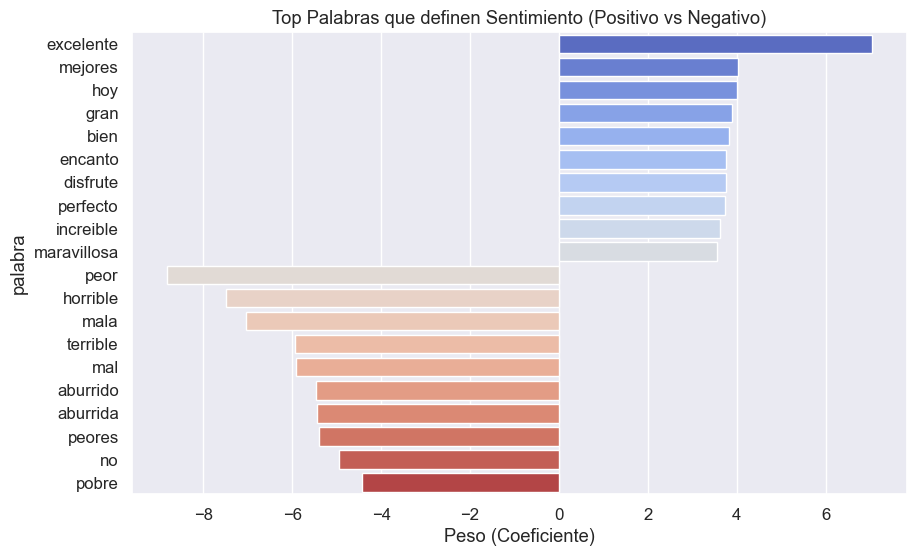

In [84]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_palabras, x='coeficiente', y='palabra', palette='coolwarm')
plt.title('Top Palabras que definen Sentimiento (Positivo vs Negativo)')
plt.xlabel('Peso (Coeficiente)')
plt.show()

#### Análisis de Errores


In [85]:
datos_test = X_test.to_frame(name='review').copy()
datos_test['real'] = y_test
datos_test['prediccion'] = y_pred

In [86]:
errores = datos_test[datos_test['real'] != datos_test['prediccion']]
print(f"Total de errores: {len(errores)} de {len(datos_test)}")

Total de errores: 1646 de 14310


In [87]:
errores.sample(10)

,review,real,prediccion
25852,de alguna manera realmente pensé que iba a dis...,0,1
16063,alquilé las noches de boogie la semana pasada ...,1,0
18564,no puedo pasar el mensaje de esta película est...,0,1
10686,esta película es una advertencia para todas la...,1,0
33786,normalmente no me gustan las películas de tele...,0,1
28011,vi este show hace unos años fue dam cuando la ...,1,0
22423,la película no fue tan grandeel libro es mejor...,1,0
19142,esta película no pudo explorar la humanidad de...,0,1
22230,una pregunta para usted una familia ve a una n...,0,1
15710,joan fontaine es barrido de pie por la subvenc...,0,1


##### Falsos Positivos (Eran negativos y se clasificaron como positivos)

Son los errores más importantes y que se tienen que destacar, dado que en los requisitos (y en general para cualquier modelo de atención al cliente) es peor ignorar los comentarios negativos y no darles atención (falsos positivos)

In [88]:
for i, row in errores[errores['prediccion'] == 1].head(3).iterrows():
    print(f"Review: {row['review'][:300]}...")
    print(f"Real: {row['real']} | Pred: {row['prediccion']}\n")

Review: si el término en sí no era geográfico y semánticamente sin sentido uno podría consultar ned kelly como western australiano para la gente abajo ned kelly estaba aparentemente un bandido de héroe popular similar a robin hood jesse james bonnie y clyde y butch cassidy y el niño sundance el descendiente...
Real: 0 | Pred: 1

Review: alquilé esta película porque esperaba que fuera uno toda la familia disfruteaunque la película es amigable para la familia mi familia no lo disfrutó porque da una visión falsa de diossi obedeces a dios y lo sigue no tienes éxito garantizadotu equipo de fútbol no siempre ganaráno te pondrás mágicamen...
Real: 0 | Pred: 1

Review: soy una gran marca para la música de neil young y con eso y el alabado brillante la película recibió en muchos círculos de prensa altindie golpeó la primera muestra de greendale que pude encontrar mi emoción fue de corta duración ya que esta historia turgida y el débil momento lírico dejó a la mayor...
Real: 0 | Pred: 1



##### Falsos Negativos (Eran positivos y se clasificaron como negativos)

In [89]:
for i, row in errores[errores['prediccion'] == 0].head(3).iterrows():
    print(f"Review: {row['review'][:300]}...")
    print(f"Real: {row['real']} | Pred: {row['prediccion']}\n")

Review: tenía años cuando este espectáculo estaba en la televisiónde lejos fue mi favoritolos actores eran muy creíblesalexandra bastedo era simplemente magnífico solo pido el dvd episodiosno tenían superpoderessolo tenían habilidades humanas superiores fuerza audición vistalos actores eran muy buenos en su...
Real: 1 | Pred: 0

Review: se divirtió viendo esta película a pesar de la sensación de que obtuve mucho tiempo que esta película estaba casi copiando a monsters inc hay bastantes cosas que son extremadamente similares entre las dos la relación entre un animal monstruo yun niño pequeño otros animales que intentan romper esa re...
Real: 1 | Pred: 0

Review: este fue uno de los peores episodios de columbo que he visto sin embargo estoy solo en la segunda temporada las actividades típicas de columbo son divertidas e irritantessus cenicientas que le causan problemas se han visto antes y el mío donde siempre se identifica de alguna manera con el asesino en...
Real: 1 | Pred: 0



#### Matriz de confusión


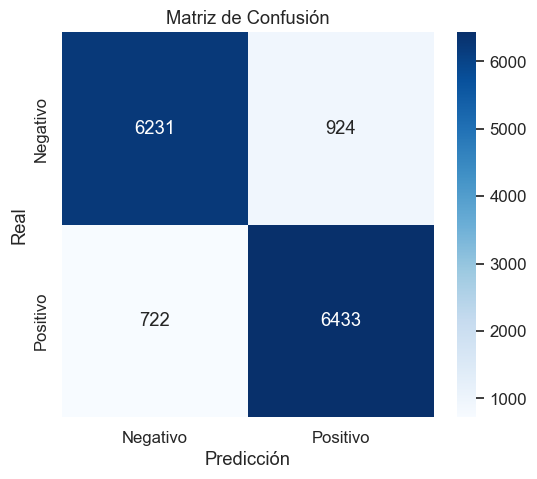

In [90]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.title('Matriz de Confusión')
plt.show()

La matriz de confusión muestra como hay un poco más de falsos positivos que de falsos negativos, para este ejemplo, nos importa mucho más las reseñas negativas para poder atender el disgusto de los clientes. Por lo tanto, es preferible tener menos falsos positivos (reseñas negativas tomadas como positivas) aunque eso conlleve a tener un poco más de falsos negativos.

#### Obtener el mejor umbral para reducir falsos positivos

In [91]:
# Mejores parametros encontados hasta el momento
"""
pipeline_test = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words = stopwords_final,
        ngram_range = (1, 3),
        max_features = 35_000,
        strip_accents='unicode',
        min_df = 2,
        max_df = 0.75,
        sublinear_tf = True
        )),
         ('clf', LogisticRegression(
             C = 10,
             random_state = 42,
             max_iter = 1000,
             class_weight = 'balanced',
             solver = 'liblinear'
             ))
         ])
"""

"\npipeline_test = Pipeline([\n    ('tfidf', TfidfVectorizer(\n        stop_words = stopwords_final,\n        ngram_range = (1, 3),\n        max_features = 35_000,\n        strip_accents='unicode',\n        min_df = 2,\n        max_df = 0.75,\n        sublinear_tf = True\n        )),\n         ('clf', LogisticRegression(\n             C = 10,\n             random_state = 42,\n             max_iter = 1000,\n             class_weight = 'balanced',\n             solver = 'liblinear'\n             ))\n         ])\n"

In [92]:
tfidf_word = TfidfVectorizer(
    analyzer = "word",
    ngram_range = (1, 2),          
    stop_words = stopwords_final,  
    strip_accents = "unicode",
    min_df = 2,
    max_df = 0.75,
    sublinear_tf = True,
    binary = True
)

tfidf_char = TfidfVectorizer(
    analyzer = "char_wb",
    ngram_range = (3, 5),          # clave para negaciones
    min_df = 2,
    max_df = 0.9,
    sublinear_tf = True
)

features = FeatureUnion([
    ("word_tfidf", tfidf_word),
    ("char_tfidf", tfidf_char)
])


In [93]:
pipeline_test = Pipeline([
    ("features", features),
    ("clf", LogisticRegression(
        C = 20,
        max_iter = 1_000,
        class_weight = "balanced",
        solver = "liblinear",
        random_state = 42
    ))
])
pipeline_test.fit(X_train, y_train)

c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['eramos', 'estabamos', 'estais', 'estan', 'estara', 'estaran', 'estaras', 'estare', 'estareis', 'estaria', 'estariais', 'estariamos', 'estarian', 'estarias', 'esteis', 'esten', 'estes', 'estuvieramos', 'estuviesemos', 'fueramos', 'fuesemos', 'habeis', 'habia', 'habiais', 'habiamos', 'habian', 'habias', 'habra', 'habran', 'habras', 'habre', 'habreis', 'habria', 'habriais', 'habriamos', 'habrian', 'habrias', 'hayais', 'hubieramos', 'hubiesemos', 'mas', 'mia', 'mias', 'mio', 'mios', 'seais', 'sera', 'seran', 'seras', 'sere', 'sereis', 'seria', 'seriais', 'seriamos', 'serian', 'serias', 'si', 'tambien', 'tendra', 'tendran', 'tendras', 'tendre', 'tendreis', 'tendria', 'tendriais', 'tendriamos', 'tendrian', 'tendrias', 'teneis', 'tengais', 'tenia', 'teniais', 'te

Pipeline(steps=[('features',
                 FeatureUnion(transformer_list=[('word_tfidf',
                                                 TfidfVectorizer(binary=True,
                                                                 max_df=0.75,
                                                                 min_df=2,
                                                                 ngram_range=(1,
                                                                              2),
                                                                 stop_words=['habrían',
                                                                             'seríamos',
                                                                             'tengo',
                                                                             'estuvierais',
                                                                             'hemos',
                                                                             'hayan',
                                                                             'tuvimos',
                                                                             'cual',
                                                                             'estuvieron',
                                                                             'nada',
                                                                             'estados',
                                                                             'sintiendo',
                                                                             'seas',
                                                                             'nuestra',
                                                                             'sobre',
                                                                             'hubieras',
                                                                             'estaban',
                                                                             'estés',
                                                                             'tenga',
                                                                             'tuvieron',
                                                                             'fuimos',
                                                                             'estuviera',
                                                                             'habréis',
                                                                             'tuyas',
                                                                             'tuvo',
                                                                             'nuestros',
                                                                             'habríamos',
                                                                             'estamos',
                                                                             'hubieran',
                                                                             'más', ...],
                                                                 strip_accents='unicode',
                                                                 sublinear_tf=True)),
                                                ('char_tfidf',
                                                 TfidfVectorizer(analyzer='char_wb',
                                                                 max_df=0.9,
                                                                 min_df=2,
                                                                 ngram_range=(3,
                                                                              5),
                                                                 sublinear_tf=True))])),
                ('clf',
                 LogisticRegression(C=20, class_weight='balanced',
                                    max_iter=1000, random_stat

In [94]:
probs = pipeline_test.predict_proba(X_test)[:, 1]

In [95]:
def probar_umbral(umbral):
    # Si la probabilidad es mayor al umbral, es 'positivo', si no 'negativo'
    preds_ajustadas = np.where(probs > umbral, 1, 0)

    # Generar matriz de confusión con el nuevo umbral
    cm = confusion_matrix(y_test, preds_ajustadas, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    return fp, fn, cm

In [96]:
umbrales = [
    0.40,
    0.45,
    0.50,
    0.51,
    0.55,
    0.58,
    0.60,
    0.61,
    0.62,
    0.63,
    0.635,
    0.64,
    0.645,
    0.65,
    0.655,
    0.66,
    0.665,
    0.67,
    0.675,
    0.68,
    0.69,
    0.70,
    0.75,
    0.80
]

In [97]:
print(f"{'Umbral':<10} {'Falsos Positivos (Riesgo)':<25} {'Falsos Negativos (Revisión extra)'}")
print("-" * 70)
for u in umbrales:
    fp, fn, _ = probar_umbral(u)
    print(f"{u:<10} {fp:<25} {fn}")

Umbral     Falsos Positivos (Riesgo) Falsos Negativos (Revisión extra)
----------------------------------------------------------------------
0.4        967                       517
0.45       875                       591
0.5        769                       670
0.51       746                       688
0.55       681                       764
0.58       633                       824
0.6        605                       879
0.61       592                       899
0.62       580                       919
0.63       559                       939
0.635      550                       952
0.64       544                       959
0.645      533                       976
0.65       527                       994
0.655      517                       1007
0.66       505                       1016
0.665      501                       1031
0.67       494                       1051
0.675      482                       1066
0.68       478                       1075
0.69       461                  

#### Usando el mejor umbral

Al tener un umbral más alto, es más estricto para que el modelo clasifique una reseña como positiva, lo que reduce significativamente la probabilidad de no atender una reseña negativa.

El mejor umbral fue de ***0.51***, con lo que se reducen la cantidad de falsos positivos, pero sin llevar a una enorme cantidad de falsos negativos.
Considerando los requisitos del proyecto, es priorizable detectar correctamente las reseñas negativas que las positivas.

In [98]:
mejor_umbral = 0.51
y_pred_final = np.where(probs > mejor_umbral, 1, 0)


--- Matriz de Confusión con Umbral 0.51 ---


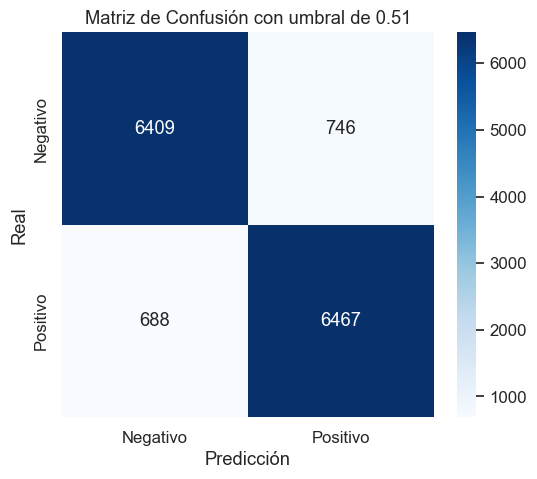

In [99]:
print(f"\n--- Matriz de Confusión con Umbral {mejor_umbral} ---")
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.title(f'Matriz de Confusión con umbral de {mejor_umbral}')
plt.show()

In [147]:
joblib.dump(pipeline_test, 'H:\Downloads\PROJECTO HACKATON\sentiment-api-equipo39\data_science\models\sentiment_model_test.joblib')

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Usuario\AppData\Local\Temp\ipykernel_11172\3670890652.py:1: SyntaxWarning: invalid escape sequence '\D'
  joblib.dump(pipeline_test, 'H:\Downloads\PROJECTO HACKATON\sentiment-api-equipo39\data_science\models\sentiment_model_test.joblib')


['H:\\Downloads\\PROJECTO HACKATON\\sentiment-api-equipo39\\data_science\\models\\sentiment_model_test.joblib']

In [148]:
modelo = joblib.load('H:\\Downloads\\PROJECTO HACKATON\\sentiment-api-equipo39\\data_science\\models\\sentiment_model_test.joblib')

In [149]:
# Simulación de predicción
texto_ejemplo = "No excelente"

In [150]:
pred_sentimiento = modelo.predict([texto_ejemplo])

c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['eramos', 'estabamos', 'estais', 'estan', 'estara', 'estaran', 'estaras', 'estare', 'estareis', 'estaria', 'estariais', 'estariamos', 'estarian', 'estarias', 'esteis', 'esten', 'estes', 'estuvieramos', 'estuviesemos', 'fueramos', 'fuesemos', 'habeis', 'habia', 'habiais', 'habiamos', 'habian', 'habias', 'habra', 'habran', 'habras', 'habre', 'habreis', 'habria', 'habriais', 'habriamos', 'habrian', 'habrias', 'hayais', 'hubieramos', 'hubiesemos', 'mas', 'mia', 'mias', 'mio', 'mios', 'seais', 'sera', 'seran', 'seras', 'sere', 'sereis', 'seria', 'seriais', 'seriamos', 'serian', 'serias', 'si', 'tambien', 'tendra', 'tendran', 'tendras', 'tendre', 'tendreis', 'tendria', 'tendriais', 'tendriamos', 'tendrian', 'tendrias', 'teneis', 'tengais', 'tenia', 'teniais', 'te

In [151]:
probabilidades = modelo.predict_proba([texto_ejemplo])

In [152]:
# Sentimiento y su probabilidad asociada (máxima probabilidad)
max_proba = np.max(probabilidades)

In [154]:
print(f"Predicción: {pred_sentimiento}, Probabilidad: {max_proba:.2f}")

Predicción: [1], Probabilidad: 1.00


In [103]:
# Score en entrenamiento
train_score = pipeline_test.score(X_train, y_train)
# Score en prueba
test_score = pipeline_test.score(X_test, y_test)

print(f"Precisión Entrenamiento: {train_score:.4f}")
print(f"Precisión Prueba: {test_score:.4f}")
print(f"Diferencia: {train_score - test_score:.4f}")

Precisión Entrenamiento: 0.9911
Precisión Prueba: 0.8871
Diferencia: 0.1040


In [104]:
from sklearn.model_selection import cross_val_score

# Usamos 5 carpetas (folds)
scores = cross_val_score(pipeline_test, X, y, cv=5)

print(f"Scores de cada carpeta: {scores}")
print(f"Promedio: {scores.mean():.4f}")
print(f"Desviación Estándar: {scores.std():.4f}") # Si es alta, el modelo es inestable

Scores de cada carpeta: [0.8927673  0.88354298 0.88710692 0.88636125 0.88877241]
Promedio: 0.8877
Desviación Estándar: 0.0030


Pesos del modelo

In [105]:
# Busca los pesos de las palabras clave
vocab = pipeline_test.named_steps['tfidf'].vocabulary_
coefs = pipeline_test.named_steps['clf'].coef_[0]
features = pipeline_test.named_steps['tfidf'].get_feature_names_out()

palabras = ['no', 'excelente', 'no excelente', 'malo']
for p in palabras:
    if p in vocab:
        idx = vocab[p]
        print(f"Token: {p:<15} | Peso: {coefs[idx]:.4f}")
    else:
        print(f"Token: {p:<15} | No está en el vocabulario")

Token: no              | Peso: -8.1808
Token: excelente       | Peso: 11.1339
Token: no excelente    | No está en el vocabulario
Token: malo            | Peso: -5.3285


## <font color=#05C0F3>**Serialización e Integración con Back-End (Java)**</font>

Esta es la fase de entrega del artefacto. El modelo entrenado y, crucialmente, el vectorizador TF-IDF (necesario para transformar el texto de entrada que envía el BE), deben ser guardados en un formato binario (joblib o pickle)

### **Definición del Pipeline de Predicción**

Para garantizar que el Back-End pueda hacer predicciones correctas, es mejor serializar el Pipeline completo: Vectorizador + Modelo.

In [140]:
tfidf_word = TfidfVectorizer(
    analyzer = "word",
    ngram_range = (1, 2),          
    stop_words = stopwords_final,  
    strip_accents = 'unicode',
    min_df = 2,
    max_df = 0.75,
    sublinear_tf = True,
    binary = True
)

tfidf_char = TfidfVectorizer(
    analyzer = "char_wb",
    ngram_range = (3, 5),
    strip_accents = 'unicode', 
    stop_words = None,        # clave para negaciones
    min_df = 2,
    max_df = 0.9,
    sublinear_tf = True
)

features = FeatureUnion([
    ("word_tfidf", tfidf_word),
    ("char_tfidf", tfidf_char)
])

In [144]:
pipeline_final = Pipeline([
    ("features", features),
    ("clf", LogisticRegression(
        C = 20,
        max_iter = 1000,
        class_weight = "balanced",
        solver = "liblinear",
        random_state = 42
    ))
])

### **Reentrenar el pipeline con X y Y**

In [145]:
pipeline_final.fit(X, y)

Pipeline(steps=[('features',
                 FeatureUnion(transformer_list=[('word_tfidf',
                                                 TfidfVectorizer(binary=True,
                                                                 max_df=0.75,
                                                                 min_df=2,
                                                                 ngram_range=(1,
                                                                              2),
                                                                 stop_words=['habrían',
                                                                             'seríamos',
                                                                             'tengo',
                                                                             'estuvierais',
                                                                             'hemos',
                                                                             'hayan',
                                                                             'tuvimos',
                                                                             'cual',
                                                                             'estuvieron',
                                                                             'nada',
                                                                             'estados',
                                                                             'sintiendo',
                                                                             'seas',
                                                                             'nuestra',
                                                                             'sobre',
                                                                             'hubieras',
                                                                             'estaban',
                                                                             'estés',
                                                                             'tenga',
                                                                             'tuvieron',
                                                                             'fuimos...
                                                                             'tuyas',
                                                                             'tuvo',
                                                                             'nuestros',
                                                                             'habríamos',
                                                                             'estamos',
                                                                             'hubieran',
                                                                             'más', ...],
                                                                 strip_accents='unicode',
                                                                 sublinear_tf=True)),
                                                ('char_tfidf',
                                                 TfidfVectorizer(analyzer='char_wb',
                                                                 max_df=0.9,
                                                                 min_df=2,
                                                                 ngram_range=(3,
                                                                              5),
                                                                 strip_accents='unicode',
                                                                 sublinear_tf=True))])),
                ('clf',
                 LogisticRegression(C=20, class_weight='balanced',
                                    max_iter=1000, random_state=42,
                                    solver='liblinear'))])

### **Serialización**

In [146]:
joblib.dump(pipeline_final, 'H:\Downloads\PROJECTO HACKATON\sentiment-api-equipo39\data_science\models\sentiment_model_1.9.joblib')

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Usuario\AppData\Local\Temp\ipykernel_20948\1075367622.py:1: SyntaxWarning: invalid escape sequence '\D'
  joblib.dump(pipeline_final, 'H:\Downloads\PROJECTO HACKATON\sentiment-api-equipo39\data_science\models\sentiment_model_1.9.joblib')


['H:\\Downloads\\PROJECTO HACKATON\\sentiment-api-equipo39\\data_science\\models\\sentiment_model_1.9.joblib']

### **Contrato de Integración y Pruebas Locales**

Prueba en Python para simular la predicción, mostrando cómo el modelo toma un texto sin procesar y genera una predicción con probabilidad.

In [157]:
modelo = joblib.load('H:\\Downloads\\PROJECTO HACKATON\\sentiment-api-equipo39\\data_science\\models\\sentiment_model_1.8.joblib')

In [158]:
# Simulación de predicción
texto_ejemplo = "Eso no es increible"

In [159]:
pred_sentimiento = modelo.predict([texto_ejemplo])

In [160]:
probabilidades = modelo.predict_proba([texto_ejemplo])
max_proba = np.max(probabilidades)
print(f"Predicción: {pred_sentimiento}, Probabilidad: {max_proba:.2f}")

Predicción: [0], Probabilidad: 0.55


#### **FastAPI**

**El siguiente codigo es de prueba y va en el archivo del proyecto en github**

~~~
# Instalaciones
# pip install fastapi uvicorn joblib scikit-learn nltk # Se ejecuta en consola

# app.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import numpy as np

# Cargar el modelo (UNA SOLA VEZ)
app = FastAPI(title="Sentiment Analysis API")

modelo = joblib.load("sentiment_model_1.1.joblib")

# Contrato de entrada (request)
class SentimentRequest(BaseModel):
    text: str
#    {
#        text: "La película fue excelente"
#    }

# Contrato de salida (response)
class SentimentResponse(BaseModel):
    prevision: str
    probabilidad: float

# Endpoint principal /sentiment
@app.post("/sentiment", response_model=SentimentResponse)
def predict_sentiment(request: SentimentRequest):

    texto = request.text.strip()

    if len(texto) < 10:
        raise HTTPException(
            status_code=400,
            detail="El texto es demasiado corto para analizar sentimiento"
        )

    pred = modelo.predict([texto])[0]
    proba = modelo.predict_proba([texto])[0]

    probabilidad_max = float(np.max(proba))

    sentimiento = "Positivo" if pred == 1 else "Negativo"

    return {
        "prevision": sentimiento,
        "probabilidad": round(probabilidad_max, 3)
    }

# Ejecutar el servidor
# uvicorn app:app --reload # Se ejecuta en consola

POST http://localhost:8000/sentiment
Content-Type: application/json
# Eso va en:
# Postman
# Swagger
# README
# documentación

# Formato
{
  "text": "La interfaz es confusa y lenta"
}
{
  "prevision": "Negativo",
  "probabilidad": 0.92
}

~~~

**Comentario Fast API (Prueba)** **NO EJECUTAR**

**El archivo de Git tendría que tener esta estrucura**

- Modelo_hackathon.ipynb
- app.py
- requirements.txt
- sentiment_model.joblib

### Archivo requirements.txt
### Dentro del archivo .txt el siguiente texto:

- fastapi
- uvicorn
- joblib
- scikit-learn
- nltk
- numpy

**Cómo ejecutarlo (Terminal)**

**CMD, Terminal o PowerShell**

- 1. cd data_science
- 2. Instalar las librerías (solo la primera vez): pip install -r requirements.txt
- 3. Encender el servidor: uvicorn app:app --reload

### Arhivo ipynb, Modelo_hackathon.ipynb
El archivo .ipynb crea el archivo (sentiment_model.joblib)
Descargar el archivo .joblib y colocarlo dentro de la estructura del Git

**Cómo ejecutarlo (Terminal)**

**CMD, Terminal o PowerShell**

- 1. Instalar las librerías (solo la primera vez): `pip install -r requirements.txt`
- 2. Encender el servidor: `uvicorn app:app --reload`